Import libraries

In [1]:
pip install scikit-optimize

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error
from skopt import BayesSearchCV
from skopt.plots import plot_convergence, plot_objective, plot_evaluations

Import dataset

In [3]:
url = "2023_Data_BiomassGasification_NED.xlsx"
Data = pd.read_excel(url, sheet_name='Normalized Data')
Data.head()

,feed_particle_size,feed_LHV,C,H,N,S,O,feed_ash,feed_moisture,feed_VM,...,other_bed,alumina,Y-alumina,calcium oxide,dolomite,olivine,silica,sand,lab,pilot
0,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
1,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
2,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
3,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
4,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1


Data splitting (70% training, 30% testing)

In [4]:
X = Data.loc[:, ~Data.columns.isin(['N2', 'H2', 'CO', 'CO2', 'CH4', 'C2Hn', 'gas_LHV', 'gas_tar', 'gas_yield', 'char_yield', 'CGE', 'CCE', 'feed_cellulose', 'feed_hemicellulose', 'feed_lignin', 'residence_time', '111.46', '205', 'atmospheric', 'slightly below atmospheric', 'feed_LHV', 'feed_VM', 'feed_FC', 'other_feed_types', 'other_feed_shape', 'batch', 'other_gas', 'other_bed', 'dolomite'])]
Y = Data.loc[:, Data.columns.isin(['H2', 'CO2', 'gas_tar'])]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=42)

Hyperparameter tuning using Bayesian optimization

In [5]:
#Define search spaces of every hyperparameter tuned in GBR
search_spaces = {
    'n_estimators': (50, 500),
    'learning_rate': (1e-3, 1.0, 'log-uniform'),
    'max_depth': (1, 20),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 20),
    'subsample': (0.1, 1.0, 'uniform'),
    'max_features': (0.1, 1.0, 'uniform')
}

#Create optimizer
opt_H2 = BayesSearchCV(
    estimator=GradientBoostingRegressor(),
    search_spaces=search_spaces,
    cv=10,
    n_iter=32,
    n_jobs=-1,
    random_state=42
)

opt_CO2 = BayesSearchCV(
    estimator=GradientBoostingRegressor(),
    search_spaces=search_spaces,
    cv=10,
    n_iter=32,
    n_jobs=-1,
    random_state=42
)

opt_Tar = BayesSearchCV(
    estimator=GradientBoostingRegressor(),
    search_spaces=search_spaces,
    cv=10,
    n_iter=32,
    n_jobs=-1,
    random_state=42
)

#Fit traning data with optimizer
opt_H2.fit(X_train, Y_train['H2'])
opt_CO2.fit(X_train, Y_train['CO2'])
opt_Tar.fit(X_train, Y_train['gas_tar'])

#Show optimization results
print('For H2 model')
print('Best parameters: ', opt_H2.best_params_)
print('Best score: ', opt_H2.best_score_)
print('--------------------------------------')
print('For CO2 model')
print('Best parameters: ', opt_CO2.best_params_)
print('Best score: ', opt_CO2.best_score_)
print('--------------------------------------')
print('For Tar model')
print('Best parameters: ', opt_Tar.best_params_)
print('Best score: ', opt_Tar.best_score_)
print('--------------------------------------')

For H2 model
Best parameters:  OrderedDict([('learning_rate', 0.1261264171763224), ('max_depth', 15), ('max_features', 0.34803871758295396), ('min_samples_leaf', 12), ('min_samples_split', 17), ('n_estimators', 363), ('subsample', 0.5682522044180047)])
Best score:  0.9393519937482762
--------------------------------------
For CO2 model
Best parameters:  OrderedDict([('learning_rate', 0.15925169151603527), ('max_depth', 19), ('max_features', 0.24724646077469525), ('min_samples_leaf', 5), ('min_samples_split', 16), ('n_estimators', 218), ('subsample', 0.5131220627357251)])
Best score:  0.8747770605722429
--------------------------------------
For Tar model
Best parameters:  OrderedDict([('learning_rate', 0.054480775484955175), ('max_depth', 19), ('max_features', 0.1), ('min_samples_leaf', 3), ('min_samples_split', 7), ('n_estimators', 491), ('subsample', 0.7935754740968534)])
Best score:  0.7427343242363484
--------------------------------------


Plots from optimization process

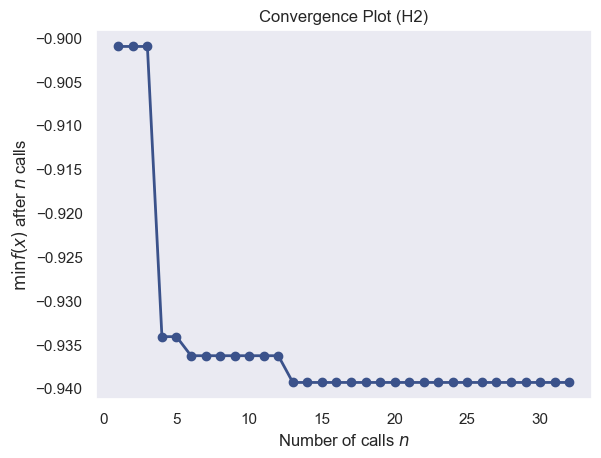

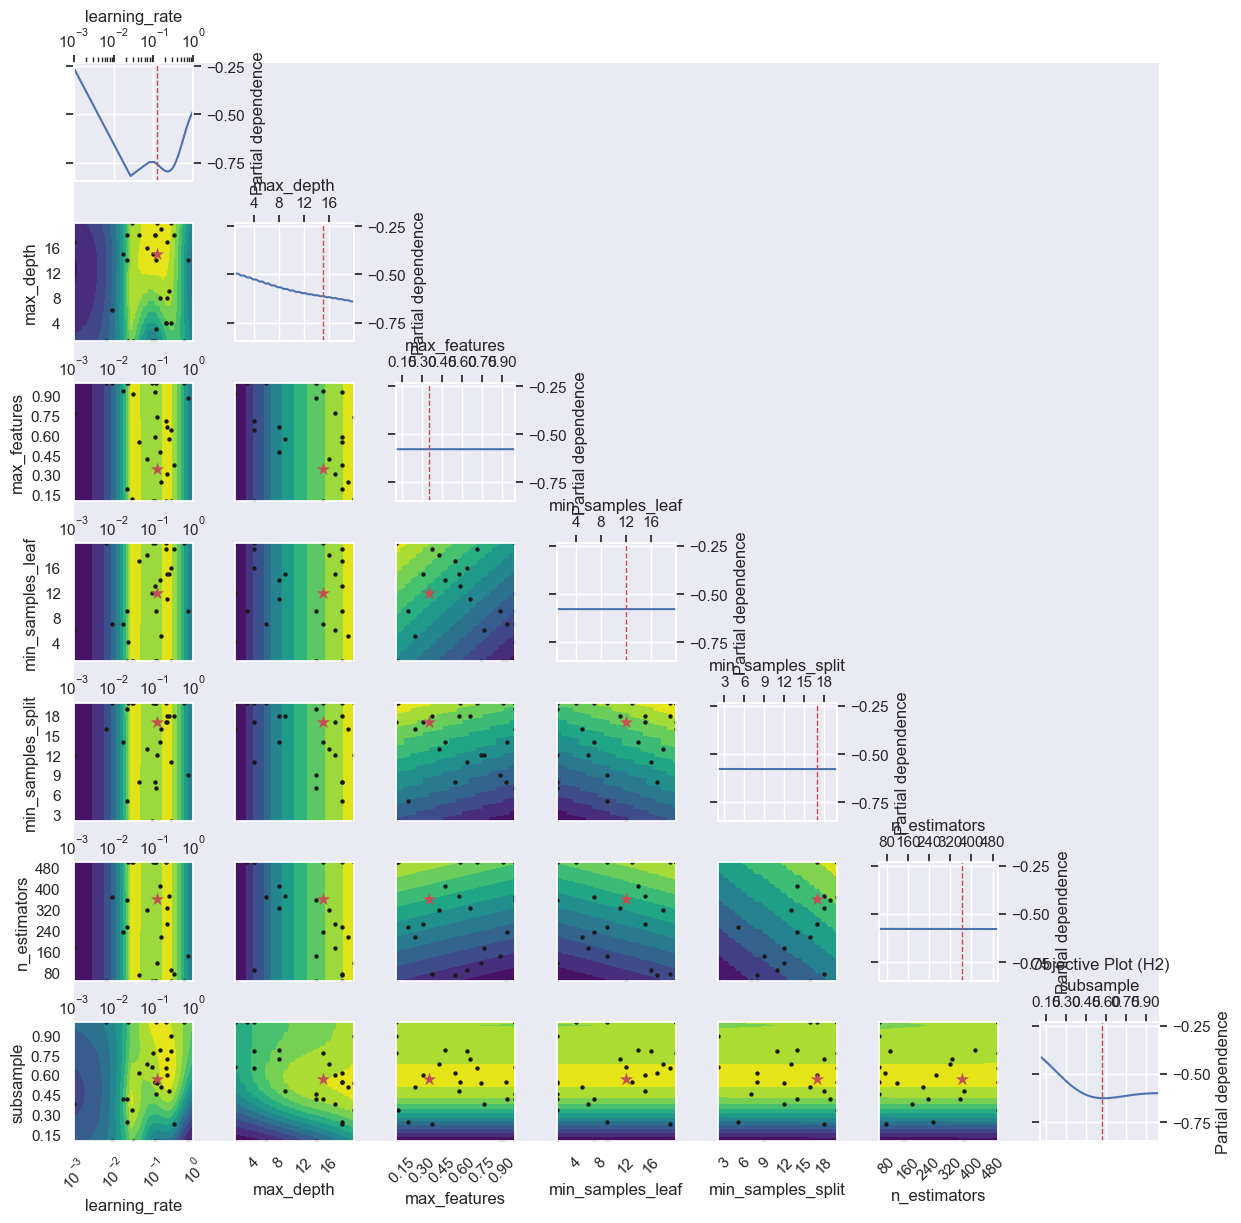

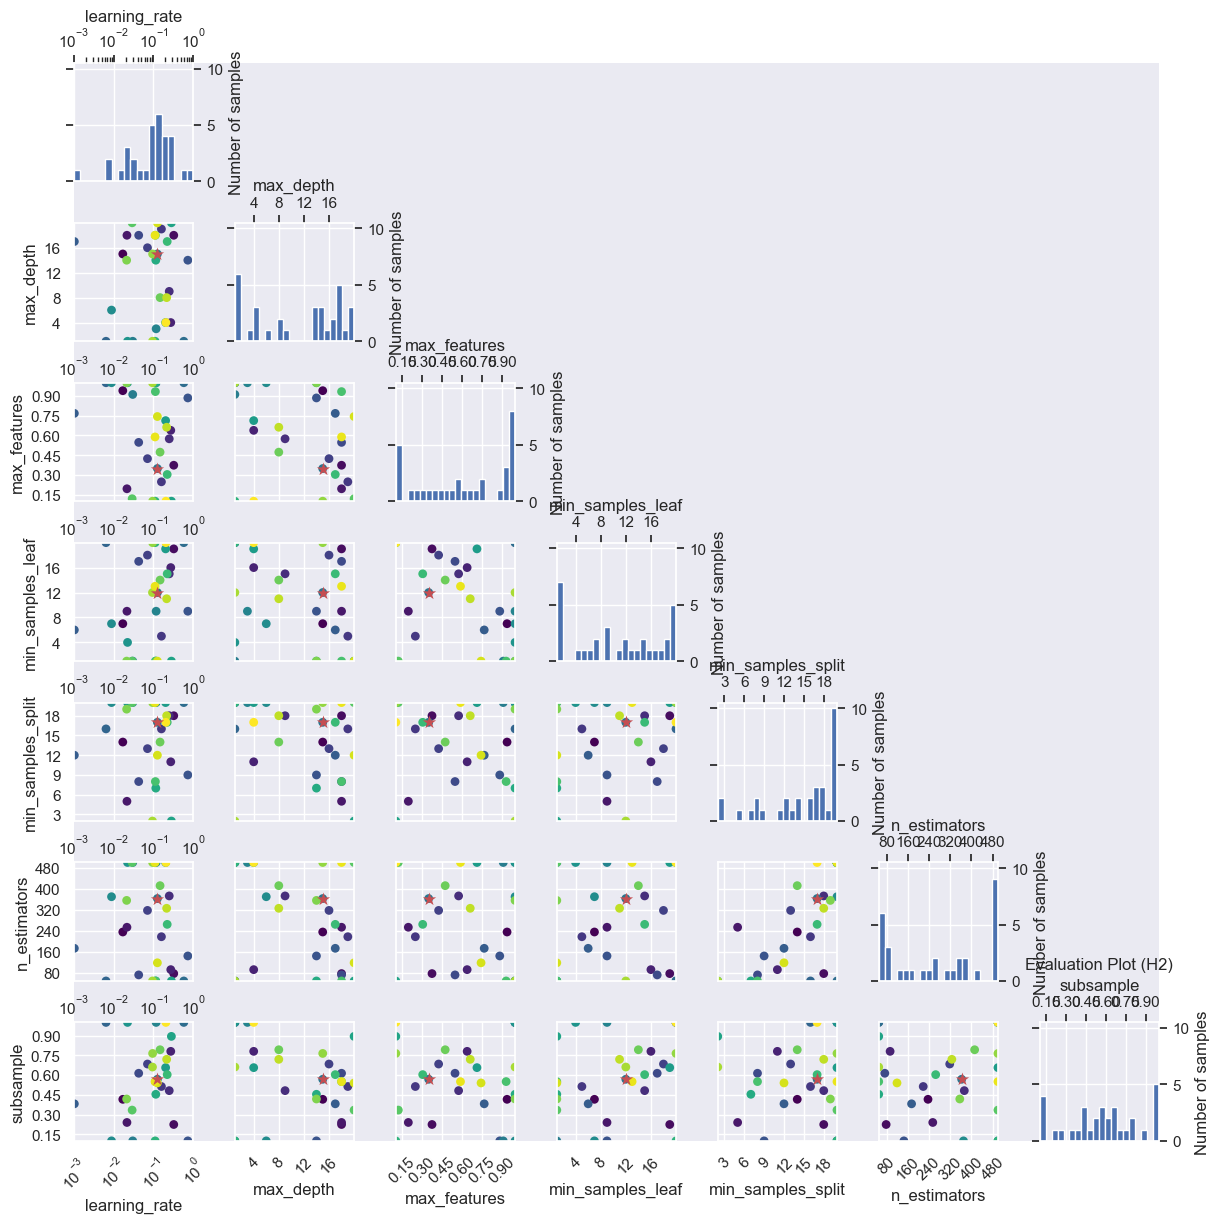

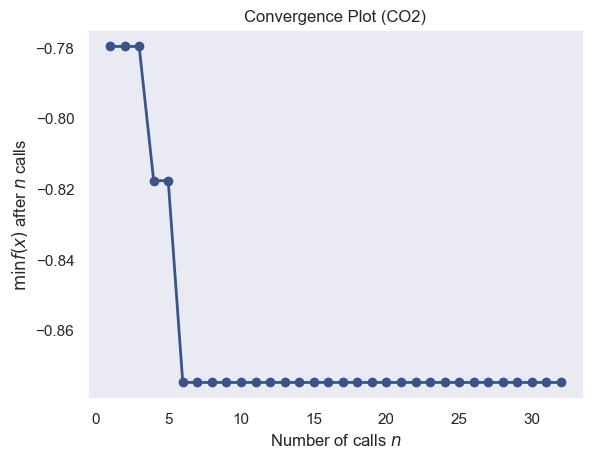

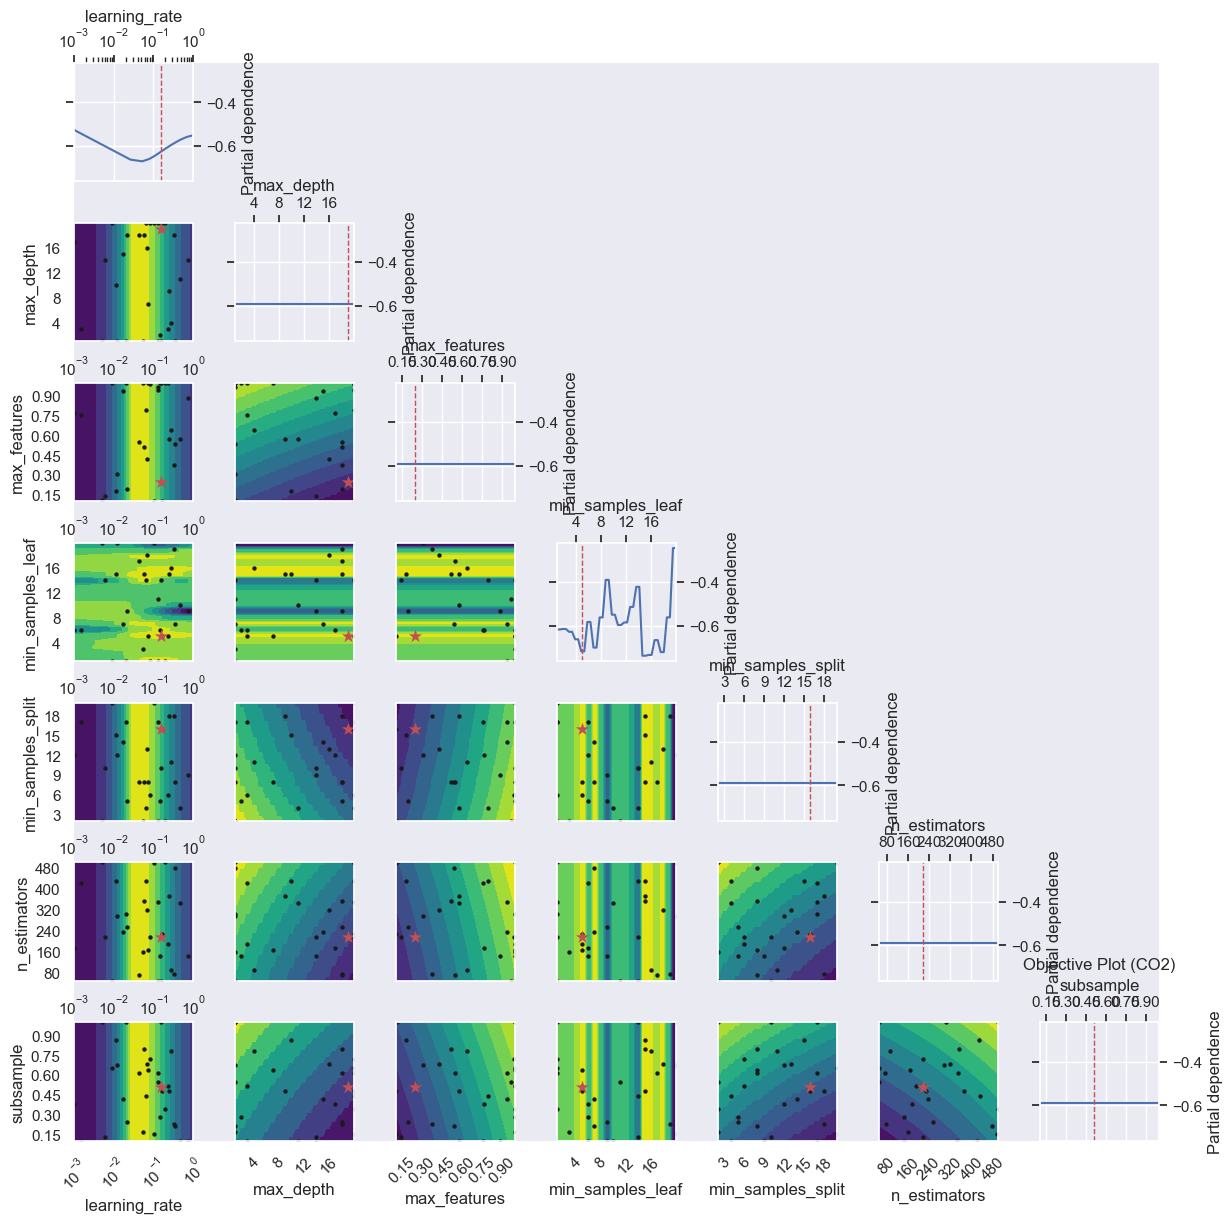

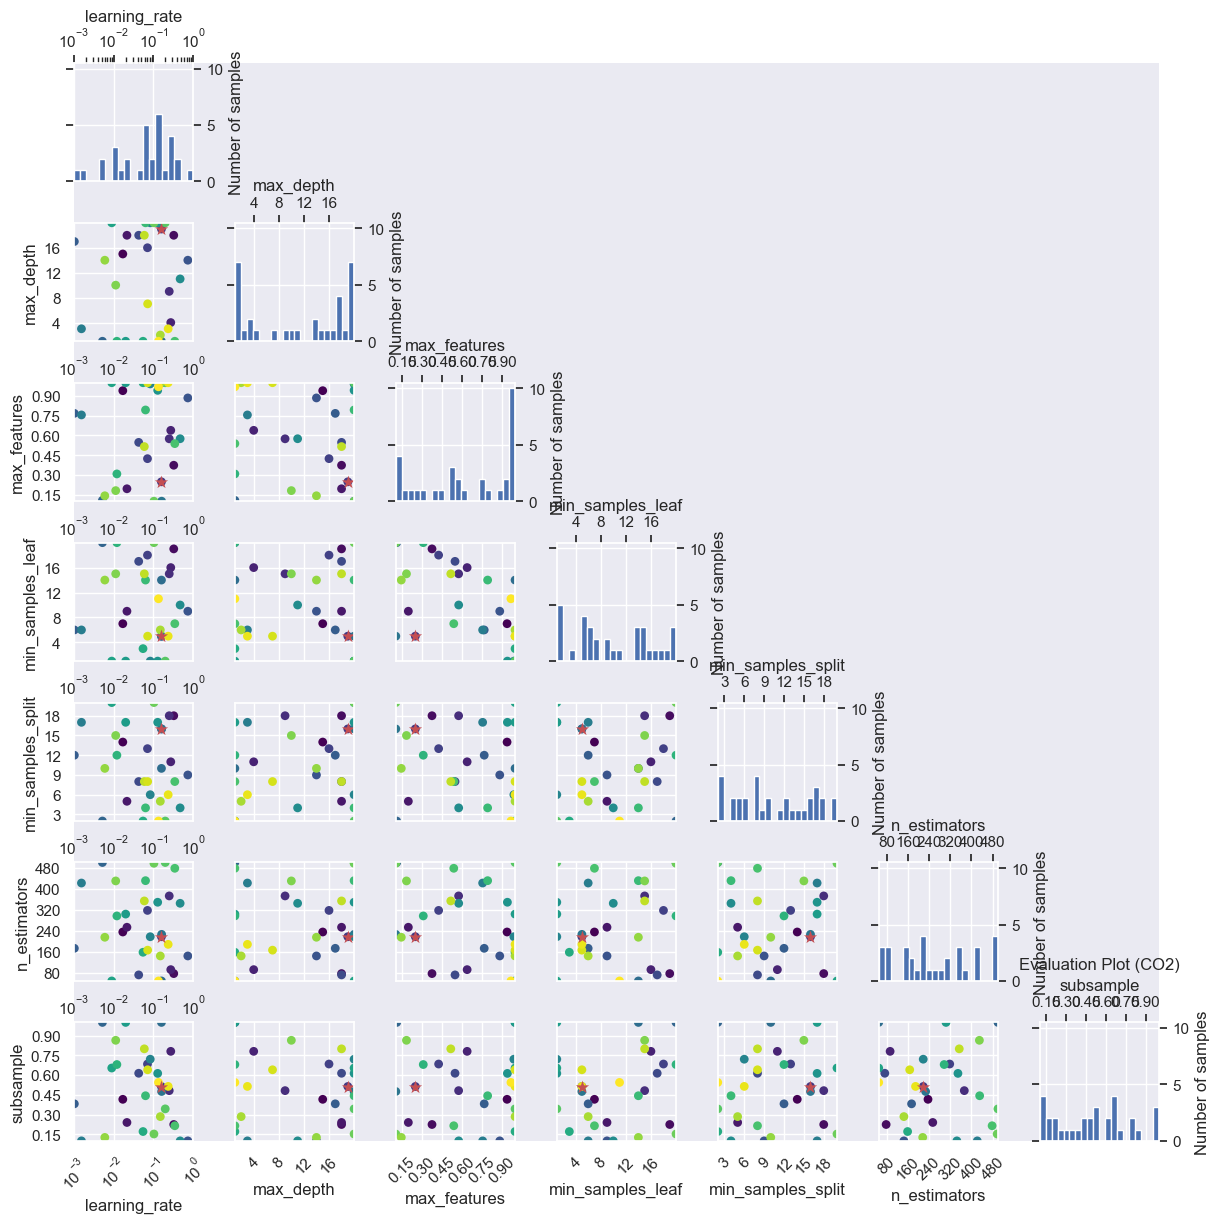

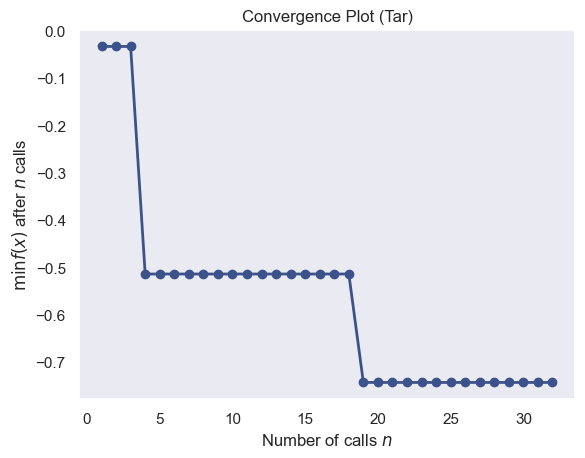

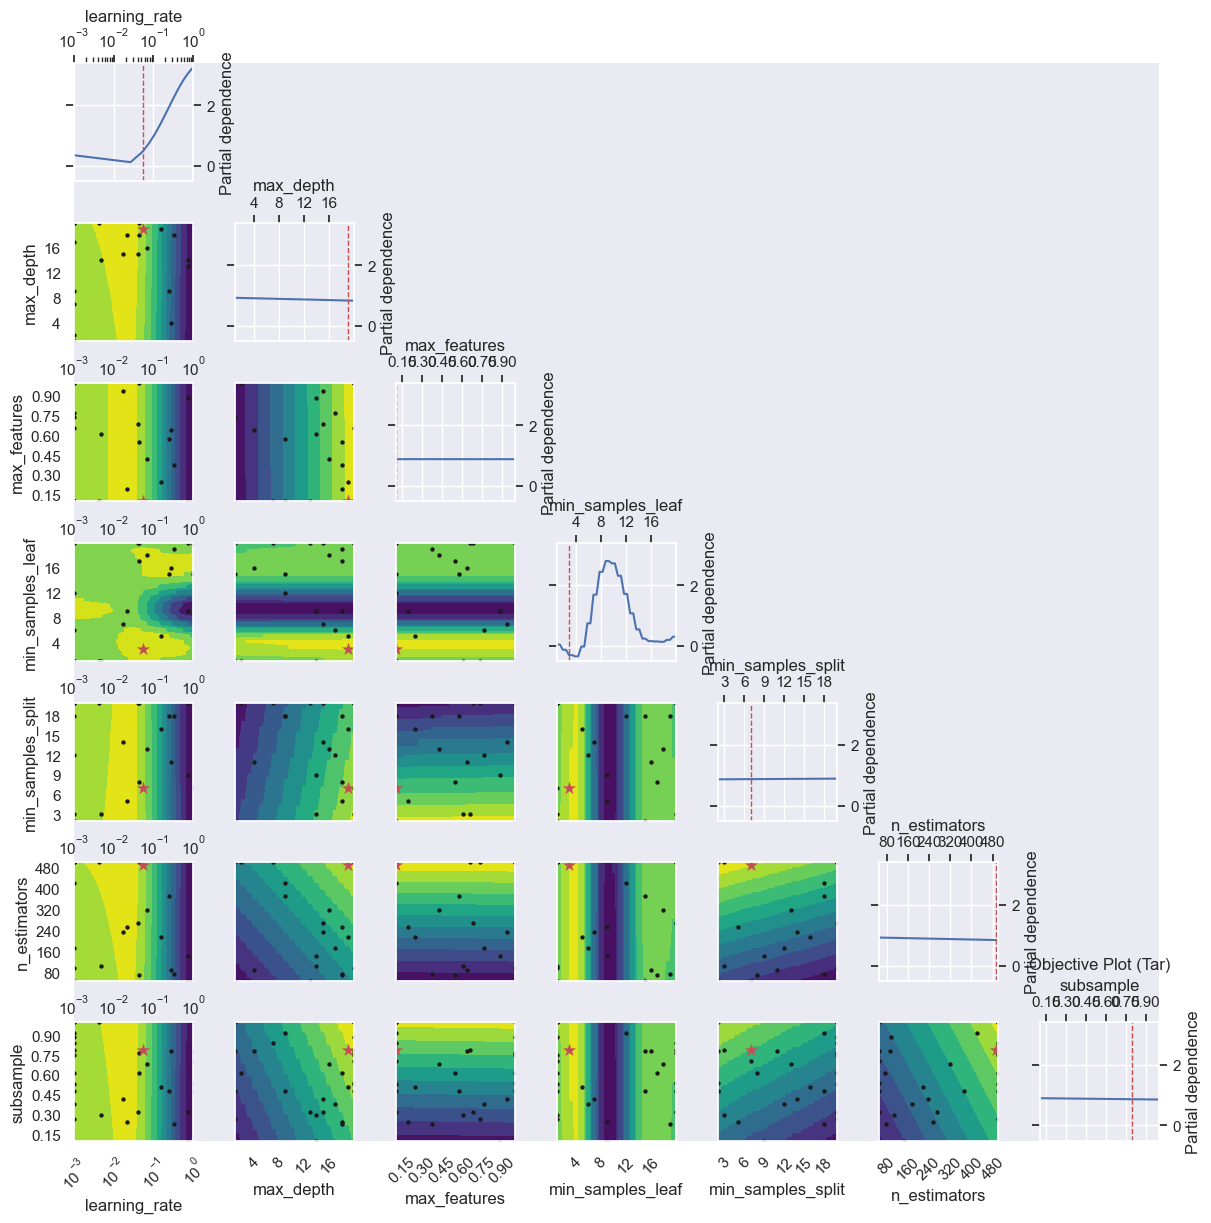

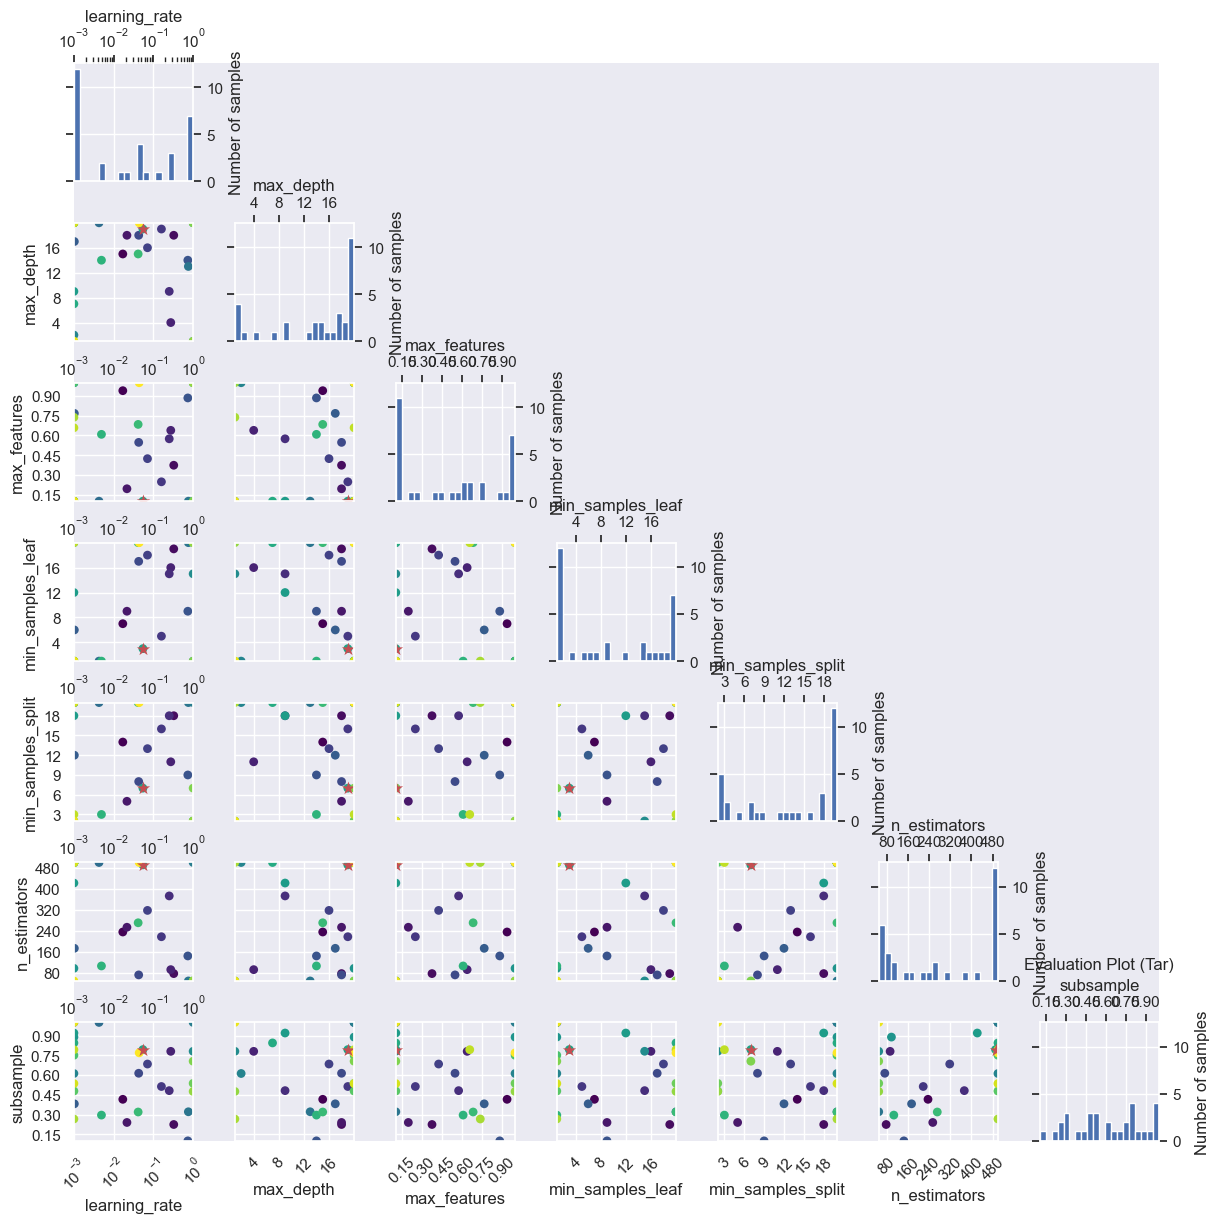

In [6]:
#Plot of H2 model
plot_convergence(opt_H2.optimizer_results_[0])
plt.title('Convergence Plot (H2)')
plt.show()

plot_objective(opt_H2.optimizer_results_[0])
plt.title('Objective Plot (H2)')
plt.show()

plot_evaluations(opt_H2.optimizer_results_[0])
plt.title('Evaluation Plot (H2)')
plt.show()

#Plot of CO2 model
plot_convergence(opt_CO2.optimizer_results_[0])
plt.title('Convergence Plot (CO2)')
plt.show()

plot_objective(opt_CO2.optimizer_results_[0])
plt.title('Objective Plot (CO2)')
plt.show()

plot_evaluations(opt_CO2.optimizer_results_[0])
plt.title('Evaluation Plot (CO2)')
plt.show()

#Plot of Tar model
plot_convergence(opt_Tar.optimizer_results_[0])
plt.title('Convergence Plot (Tar)')
plt.show()

plot_objective(opt_Tar.optimizer_results_[0])
plt.title('Objective Plot (Tar)')
plt.show()

plot_evaluations(opt_Tar.optimizer_results_[0])
plt.title('Evaluation Plot (Tar)')
plt.show()

Model training

In [7]:
#model configuration using the tuned hyperparameter
model_H2 = GradientBoostingRegressor(n_estimators=opt_H2.best_params_['n_estimators'],
                                     learning_rate=opt_H2.best_params_['learning_rate'],
                                     max_depth=opt_H2.best_params_['max_depth'],
                                     min_samples_leaf=opt_H2.best_params_['min_samples_leaf'],
                                     min_samples_split=opt_H2.best_params_['min_samples_split'],
                                     subsample=opt_H2.best_params_['subsample'],
                                     max_features=opt_H2.best_params_['max_features'])

model_CO2 = GradientBoostingRegressor(n_estimators=opt_CO2.best_params_['n_estimators'],
                                     learning_rate=opt_CO2.best_params_['learning_rate'],
                                     max_depth=opt_CO2.best_params_['max_depth'],
                                     min_samples_split=opt_CO2.best_params_['min_samples_split'],
                                     min_samples_leaf=opt_CO2.best_params_['min_samples_leaf'],
                                     subsample=opt_CO2.best_params_['subsample'],
                                     max_features=opt_CO2.best_params_['max_features'])

model_Tar = GradientBoostingRegressor(n_estimators=opt_Tar.best_params_['n_estimators'],
                                     learning_rate=opt_Tar.best_params_['learning_rate'],
                                     max_depth=opt_Tar.best_params_['max_depth'],
                                      min_samples_split=opt_Tar.best_params_['min_samples_split'],
                                      min_samples_leaf=opt_Tar.best_params_['min_samples_leaf'],
                                      subsample=opt_Tar.best_params_['subsample'],
                                      max_features=opt_Tar.best_params_['max_features'])

#FIt model with training data
model_H2.fit(X_train, Y_train['H2'])
model_CO2.fit(X_train, Y_train['CO2'])
model_Tar.fit(X_train, Y_train['gas_tar'])

#Model evaluation with training dataset
Y_predict_H2 = model_H2.predict(X_train)
Y_predict_CO2 = model_CO2.predict(X_train)
Y_predict_Tar = model_Tar.predict(X_train)

Predict_train = pd.DataFrame({'H2': Y_predict_H2.flatten(),
                              'CO2': Y_predict_CO2.flatten(),
                              'gas_tar': Y_predict_Tar.flatten()})

for i in ['H2', 'CO2', 'gas_tar']:
  R2 = r2_score(Y_train[i], Predict_train[i])
  MSE = mean_squared_error(Y_train[i], Predict_train[i])
  print(f'Evaluation score of {i} model;')
  print(f'R2 score: {R2:.2f}')
  print(f'MSE: {MSE:.2f}')
  print('-----------------------------')

Evaluation score of H2 model;
R2 score: 0.99
MSE: 0.00
-----------------------------
Evaluation score of CO2 model;
R2 score: 0.99
MSE: 0.00
-----------------------------
Evaluation score of gas_tar model;
R2 score: 1.00
MSE: 0.00
-----------------------------


Model testing

In [8]:
Y_predict_H2 = model_H2.predict(X_test)
Y_predict_CO2 = model_CO2.predict(X_test)
Y_predict_Tar = model_Tar.predict(X_test)

Predict_test = pd.DataFrame({'H2': Y_predict_H2.flatten(),
                              'CO2': Y_predict_CO2.flatten(),
                              'gas_tar': Y_predict_Tar.flatten()})

for i in ['H2', 'CO2', 'gas_tar']:
  R2 = r2_score(Y_test[i], Predict_test[i])
  MSE = mean_squared_error(Y_test[i], Predict_test[i])
  print(f'Evaluation score of {i} model;')
  print(f'R2 score: {R2:.2f}')
  print(f'MSE: {MSE:.2f}')
  print('-----------------------------')

Evaluation score of H2 model;
R2 score: 0.92
MSE: 0.00
-----------------------------
Evaluation score of CO2 model;
R2 score: 0.91
MSE: 0.00
-----------------------------
Evaluation score of gas_tar model;
R2 score: 0.58
MSE: 0.00
-----------------------------


Plot of Actual vs Prediction

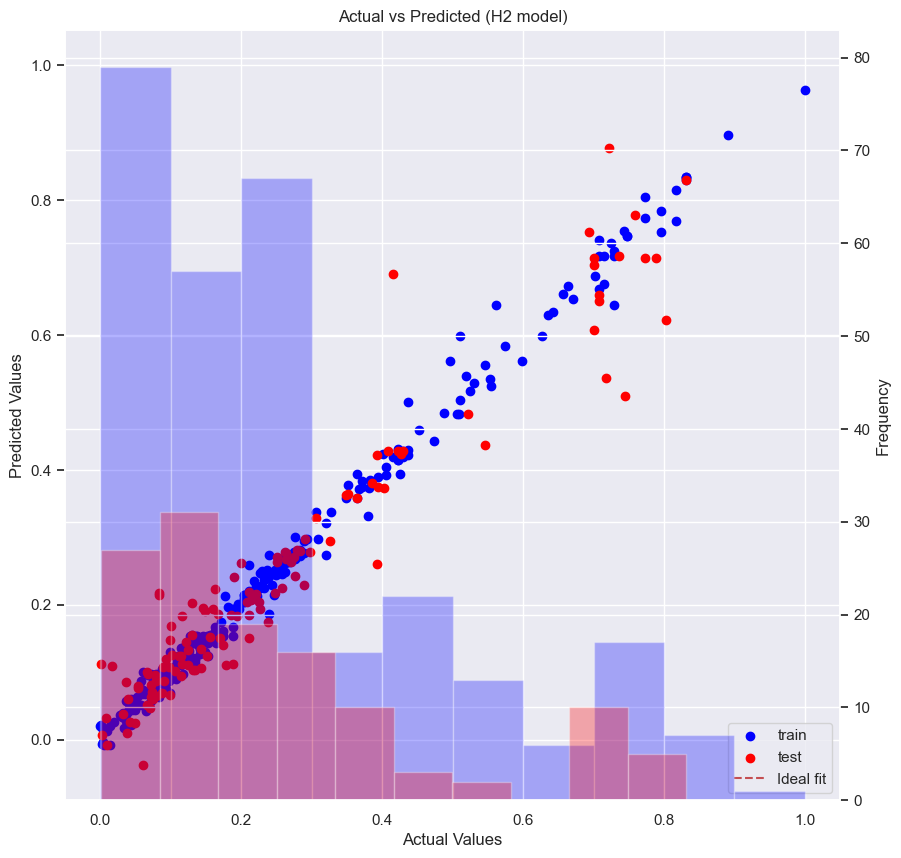

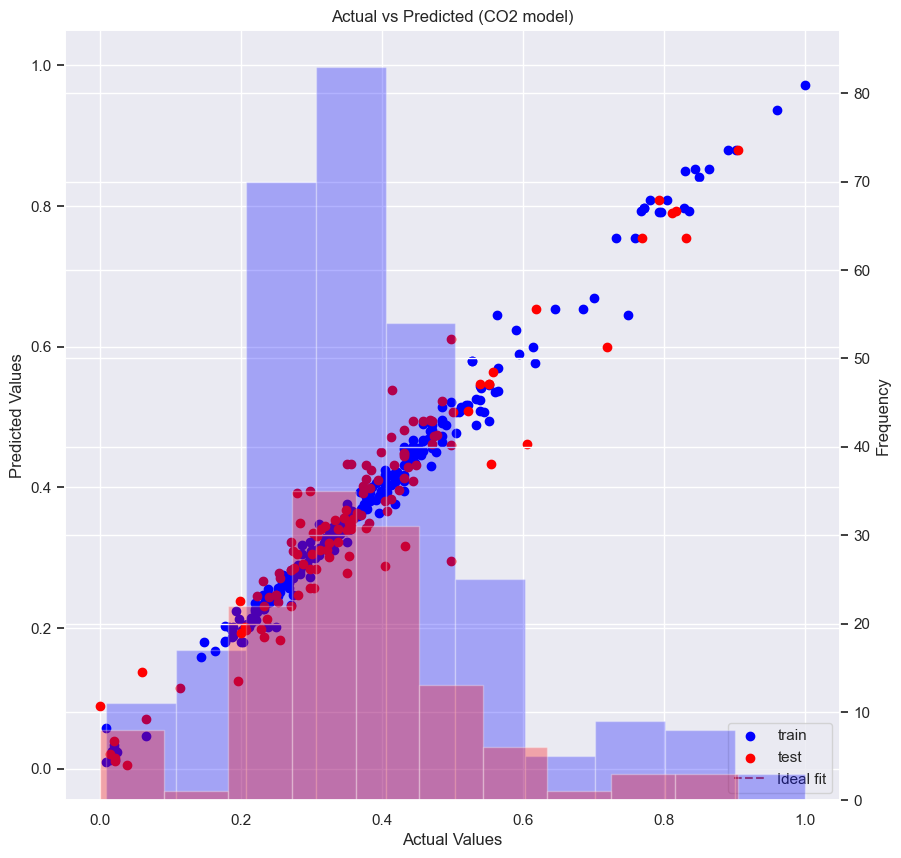

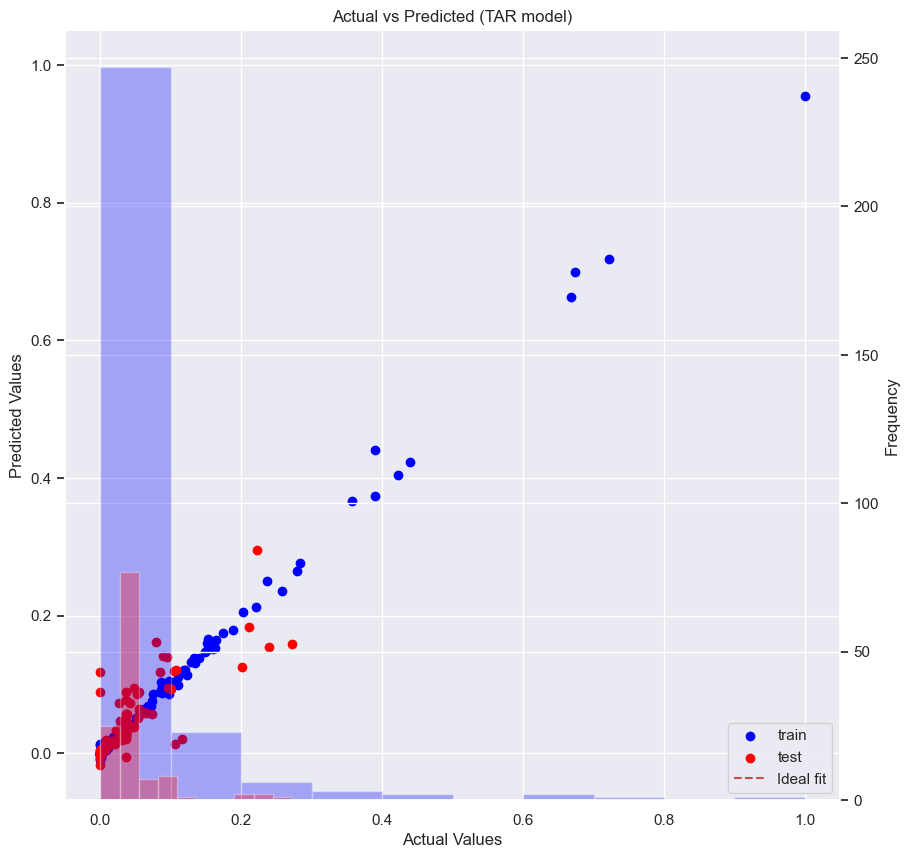

In [15]:
for model in ['H2', 'CO2', 'gas_tar']:
  fig, ax1 = plt.subplots(figsize=(10,10))
  ax1.scatter(Y_train[model], Predict_train[model], color='blue', label='train')
  ax1.scatter(Y_test[model], Predict_test[model], color='red', label='test')
  ax1.plot([0,0], [1,1], 'r--', label='Ideal fit')
  ax1.set_xlabel('Actual Values')
  ax1.set_ylabel('Predicted Values')
  ax1.legend()

  ax2 = ax1.twinx()
  ax2.hist(Y_train[model], bins=10, alpha=0.3, color='blue')
  ax2.hist(Y_test[model], bins=10, alpha=0.3, color='red')
  ax2.set_ylabel('Frequency')
  
  if model == 'gas_tar':
    model = 'TAR'
  plt.title(f'Actual vs Predicted ({model} model)')
  plt.show()